# Deep EDA: Viabilidad de Propagación en UNSW-NB15
## Evaluación de Grafos y Modelos SIR/SEIR

Este análisis profundiza en la estructura de red del dataset para determinar si es viable aplicar modelos epidemiológicos de propagación de amenazas.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import sys
from pathlib import Path

# Agregar src al path para importar el cargador
sys.path.append('../src')
from data.unsw_loader import UNSWLoader

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
print("✓ Librerías cargadas")

✓ Librerías cargadas


## 1. Carga de Datos Consolidada
Cargamos una muestra significativa para analizar la conectividad global.

In [2]:
loader = UNSWLoader('../data/raw/unsw-nb15')
df = loader.load_consolidated_sample(nrows_per_file=250000)

# Limpieza básica de categorías
df['attack_cat'] = df['attack_cat'].str.strip().fillna('Normal')
df.loc[df['Label'] == 0, 'attack_cat'] = 'Normal'

print(f"\n✓ Dataset cargado: {df.shape[0]:,} flujos de red")

Reading sample from UNSW-NB15_1.csv...
Reading sample from UNSW-NB15_2.csv...
Reading sample from UNSW-NB15_3.csv...
Reading sample from UNSW-NB15_4.csv...

✓ Dataset cargado: 1,000,000 flujos de red


## 2. Análisis de Estructura
Revisamos las columnas clave para el grafo (IPs) y el modelo (Labels).

In [3]:
print("Columnas clave para el proyecto:")
key_cols = ['srcip', 'dstip', 'proto', 'service', 'attack_cat', 'Label']
display(df[key_cols].head())

Columnas clave para el proyecto:


,srcip,dstip,proto,service,attack_cat,Label
0,59.166.0.0,149.171.126.6,udp,dns,Normal,0
1,59.166.0.0,149.171.126.9,udp,-,Normal,0
2,59.166.0.6,149.171.126.7,udp,dns,Normal,0
3,59.166.0.5,149.171.126.5,udp,dns,Normal,0
4,59.166.0.3,149.171.126.0,udp,dns,Normal,0


## 3. Construcción del Grafo de Conectividad
Mapeamos todos los flujos de comunicación como aristas en un grafo.

In [4]:
print("Construyendo grafo...")
G = nx.from_pandas_edgelist(df, source='srcip', target='dstip', 
                            edge_attr=['proto', 'service', 'attack_cat', 'Label'], 
                            create_using=nx.DiGraph())

print(f"✓ Grafo construido")
print(f"  - Nodos (IPs): {G.number_of_nodes()}")
print(f"  - Aristas (Comunicaciones): {G.number_of_edges()}")

Construyendo grafo...
✓ Grafo construido
  - Nodos (IPs): 48
  - Aristas (Comunicaciones): 296


## 4. Métricas de Viabilidad de Red
Calculamos métricas para evaluar si la topología permite la propagación.

In [5]:
density = nx.density(G)
avg_degree = sum(dict(G.degree()).values()) / G.number_of_nodes()

print(f"Densidad del grafo: {density:.6f}")
print(f"Grado promedio (conexiones por IP): {avg_degree:.2f}")

# Componentes conectados (usando grafo no dirigido para alcance total)
U = G.to_undirected()
components = list(nx.connected_components(U))
print(f"Número de subredes aisladas: {len(components)}")
print(f"Tamaño de la subred más grande (LCC): {len(max(components, key=len))}")

Densidad del grafo: 0.131206
Grado promedio (conexiones por IP): 12.33
Número de subredes aisladas: 4
Tamaño de la subred más grande (LCC): 26


## 5. Análisis de Alcance de Amenazas (Worms/Backdoors)
¿Cuántos nodos puede 'tocar' un Gusano basándose en la topología real?

### Justificación del Modelo Epidemiológico (SIR/SEIR)
Se han seleccionado específicamente las categorías de **Worms** (Gusanos) y **Backdoors** para el modelado SIR/SEIR por las siguientes razones:

1. **Naturaleza Viral**: Los Worms están diseñados para autoreplicarse y propagarse de forma autónoma a través de las conexiones de red, lo que coincide directamente con la tasa de infección ($\beta$) en modelos epidemiológicos.
2. **Estados de Transición**: El comportamiento de estas amenazas permite mapear claramente los estados:
   - **S (Susceptible)**: Nodos sanos en la topología analizada.
   - **E (Expuesto)**: Nodos que han recibido flujos maliciosos (latencia), ideal para el modelo SEIR.
   - **I (Infectado)**: Nodos que activamente intentan propagar el ataque a sus vecinos en el grafo.
   - **R (Recuperado)**: Nodos que han sido aislados o parcheados tras detectar la amenaza.
3. **Dependencia de la Topología**: A diferencia de ataques puntuales (como DoS), la propagación viral depende de la estructura de red (quién habla con quién), validando el análisis de grafos realizado anteriormente.

In [6]:
viral_categories = ['Worms', 'Backdoors']
infectious_flows = df[df['attack_cat'].isin(viral_categories)]
infectors = infectious_flows['srcip'].unique()

print(f"Nodos identificados como fuentes de infección: {len(infectors)}")

# Calcular alcance desde un infector promedio
if len(infectors) > 0:
    sample_infector = infectors[0]
    reachable = nx.descendants(G, sample_infector)
    print(f"\nAnálisis para Infector de Ejemplo ({sample_infector}):")
    print(f"  - Alcance directo e indirecto: {len(reachable)} nodos")
    print(f"  - % de la red que puede infectar: {(len(reachable)/G.number_of_nodes())*100:.2f}%")

Nodos identificados como fuentes de infección: 4

Análisis para Infector de Ejemplo (175.45.176.2):
  - Alcance directo e indirecto: 15 nodos
  - % de la red que puede infectar: 31.25%


## 6. Análisis Estadístico Descriptivo
Calculamos métricas clave (media, moda, etc.) para entender la naturaleza del tráfico y los ataques.

### Glosario de Variables Analizadas
Para entender las métricas estadísticas, definimos las variables clave extraídas del dataset UNSW-NB15:

*   **`dur`**: Duración total del flujo en segundos.
*   **`Spkts` / `Dpkts`**: Número total de paquetes enviados por el Origen (Source) y el Destino (Destination).
*   **`sbytes` / `dbytes`**: Volumen total de datos en bytes enviados por el Origen y el Destino.
*   **`Sload` / `Dload`**: Tasa de transferencia (bits por segundo) del Origen y del Destino.
*   **`smeansz` / `dmeansz`**: Tamaño promedio de los paquetes enviados por el Origen y el Destino (en bytes).

In [7]:
num_cols = ['dur', 'Spkts', 'Dpkts', 'sbytes', 'dbytes', 'Sload', 'Dload', 'smeansz', 'dmeansz']

print("Métricas Estadísticas Globales (Tráfico Consolidado):")
stats_global = df[num_cols].describe().T
stats_global['mode'] = df[num_cols].mode().iloc[0]
display(stats_global[['mean', '50%', 'mode', 'std', 'min', 'max']])

print("\nDistribución de Categorías de Ataque:")
display(df['attack_cat'].value_counts())

print("\n✓ Estadísticas calculadas")

Métricas Estadísticas Globales (Tráfico Consolidado):


,mean,50%,mode,std,min,max
dur,5.988821e-01,0.014298,9.000000e-06,3.427881e+00,0.0,5.999999e+01
Spkts,3.188152e+01,12.000000,2.000000e+00,7.491374e+01,0.0,1.020000e+04
Dpkts,4.049109e+01,12.000000,0.000000e+00,1.164843e+02,0.0,1.097400e+04
sbytes,4.262270e+03,1294.000000,1.460000e+02,5.879753e+04,0.0,1.367739e+07
dbytes,3.405899e+04,1644.000000,0.000000e+00,1.541821e+05,0.0,1.465555e+07
Sload,3.847400e+07,601571.968750,5.066666e+07,1.210544e+08,0.0,5.988000e+09
Dload,2.436705e+06,586008.187500,0.000000e+00,4.220593e+06,0.0,4.807207e+07
smeansz,1.240558e+02,73.000000,1.320000e+02,1.512135e+02,0.0,1.504000e+03
dmeansz,2.698760e+02,89.000000,0.000000e+00,3.313017e+02,0.0,1.500000e+03



Distribución de Categorías de Ataque:


attack_cat
Normal            870845
Generic            84642
Exploits           18635
Fuzzers            11123
DoS                 5939
Reconnaissance      5677
Analysis            1208
Backdoor             677
Shellcode            649
Backdoors            534
Worms                 71
Name: count, dtype: int64


✓ Estadísticas calculadas


### 6.1 Comparativa por Categoría de Ataque
Analizamos cómo varían los tamaños de paquetes y volumen de datos según el tipo de amenaza.

In [8]:
print("Promedio de métricas por categoría de ataque:")
grouped_stats = df.groupby('attack_cat')[num_cols].mean()
display(grouped_stats.sort_values(by='sbytes', ascending=False))

print("\nMediana de métricas por categoría de ataque:")
display(df.groupby('attack_cat')[num_cols].median().sort_values(by='sbytes', ascending=False))

Promedio de métricas por categoría de ataque:


,dur,Spkts,Dpkts,sbytes,dbytes,Sload,Dload,smeansz,dmeansz
attack_cat,,,,,,,,,
Exploits,1.884638,34.629890,24.166998,30612.195224,18382.577837,5.971612e+07,6.062213e+04,192.104803,184.831554
DoS,2.564475,28.054386,26.543694,21606.809396,27595.060448,1.180938e+08,1.947066e+04,145.082169,56.752315
Fuzzers,2.447955,13.471905,6.131080,6742.797986,653.765801,1.302579e+08,3.463118e+03,242.254428,39.536816
Normal,0.583768,35.195284,45.561830,3960.639776,38370.097353,2.985609e+07,2.796275e+06,127.364114,304.115716
Worms,1.195361,17.830986,63.464789,1822.197183,77338.732394,6.244478e+07,1.414172e+05,179.676056,254.098592
Backdoor,2.100534,6.735598,1.420975,1559.778434,219.949778,1.276811e+08,2.333360e+03,102.954210,16.822747
Analysis,1.027252,4.800497,1.609272,883.380795,220.399007,1.236887e+08,1.684631e+03,99.410596,24.629139
Reconnaissance,0.903530,7.308790,6.841289,716.542012,4066.129646,6.671175e+07,2.813130e+03,77.626916,25.655276
Backdoors,0.921315,4.116105,0.749064,569.149813,160.700375,1.238969e+08,1.484145e+03,99.541199,9.078652



Mediana de métricas por categoría de ataque:


,dur,Spkts,Dpkts,sbytes,dbytes,Sload,Dload,smeansz,dmeansz
attack_cat,,,,,,,,,
Normal,0.018800,14.0,18.0,1580.0,2456.0,5.645587e+05,656000.000000,73.0,93.0
Worms,0.544761,10.0,6.0,1302.0,268.0,1.694688e+04,3764.002197,130.0,45.0
Exploits,0.521589,10.0,8.0,850.0,370.0,2.745868e+04,4536.466309,100.0,45.0
Fuzzers,0.559064,10.0,6.0,800.0,268.0,2.051838e+04,2499.843262,95.0,44.0
Reconnaissance,0.242100,10.0,6.0,564.0,268.0,2.432746e+04,1208.942261,84.0,44.0
Shellcode,0.000021,2.0,0.0,536.0,0.0,3.663158e+07,0.000000,87.0,0.0
Analysis,0.000009,2.0,0.0,200.0,0.0,8.888889e+07,0.000000,100.0,0.0
Backdoors,0.000008,2.0,0.0,200.0,0.0,8.000000e+07,0.000000,100.0,0.0
Backdoor,0.000009,2.0,0.0,200.0,0.0,8.888889e+07,0.000000,100.0,0.0


### 6.2 Visualización de Distribuciones Estadísticas
Usamos Boxplots para comparar la dispersión del tamaño de paquetes entre categorías.

C:\Users\Arnold's\AppData\Local\Temp\ipykernel_11284\3671039117.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='attack_cat', y='smeansz', palette='viridis')
C:\Users\Arnold's\AppData\Local\Temp\ipykernel_11284\3671039117.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='attack_cat', y='Spkts', palette='magma')


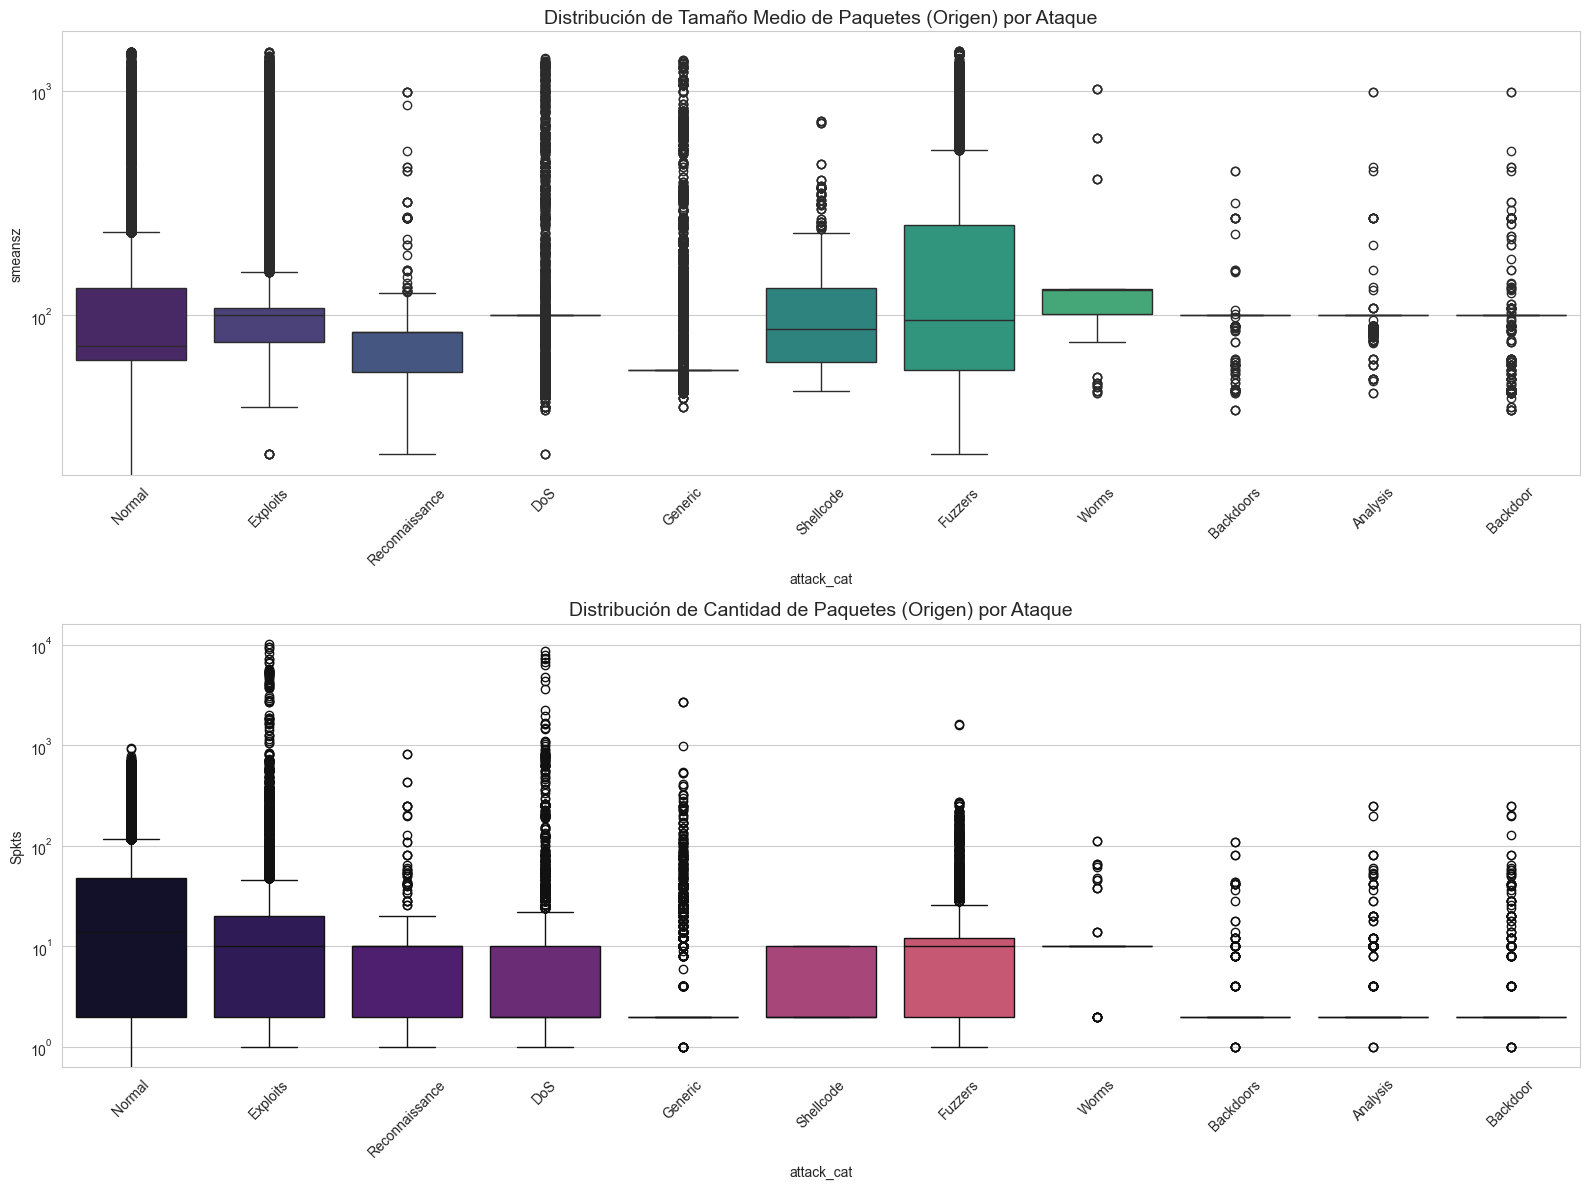

In [9]:
plt.figure(figsize=(16, 12))

plt.subplot(2, 1, 1)
sns.boxplot(data=df, x='attack_cat', y='smeansz', palette='viridis')
plt.yscale('log')
plt.title('Distribución de Tamaño Medio de Paquetes (Origen) por Ataque', fontsize=14)
plt.xticks(rotation=45)

plt.subplot(2, 1, 2)
sns.boxplot(data=df, x='attack_cat', y='Spkts', palette='magma')
plt.yscale('log')
plt.title('Distribución de Cantidad de Paquetes (Origen) por Ataque', fontsize=14)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 7. Visualización del Grafo de Ataque
Visualizamos el subgrafo de infecciones virales.

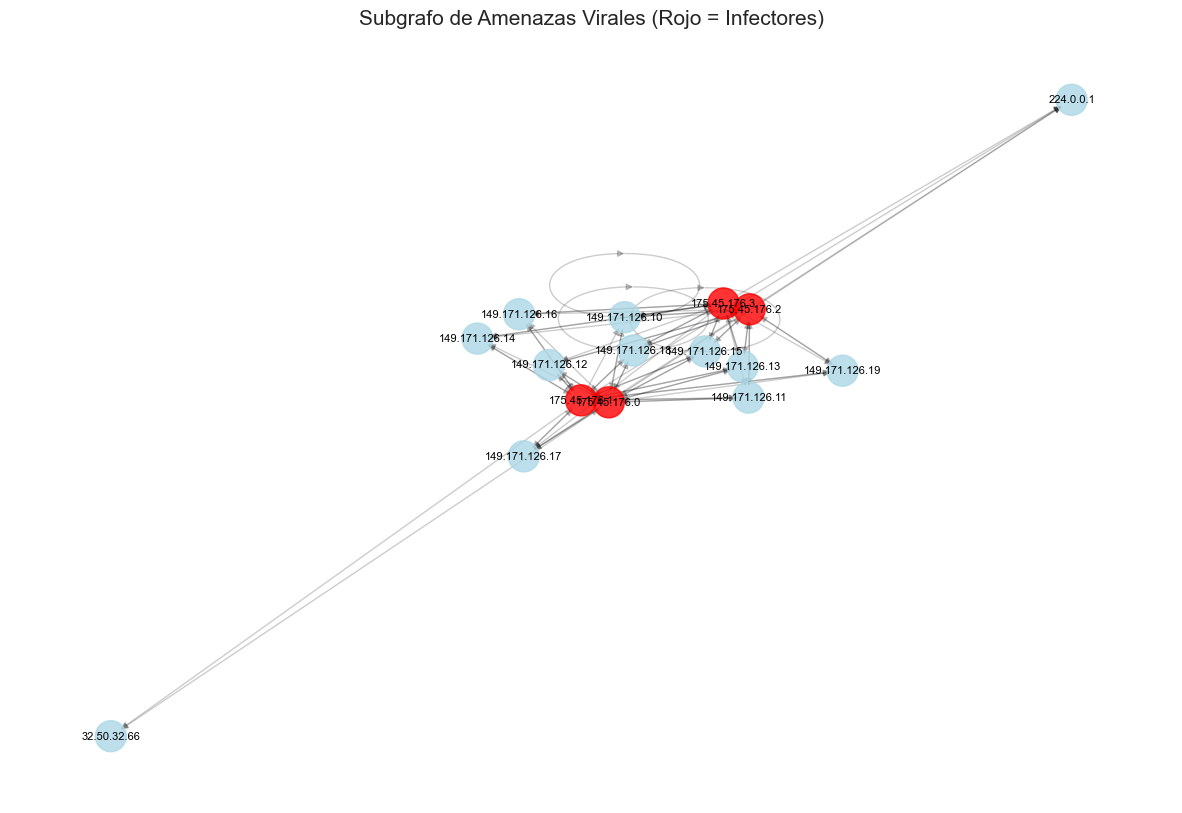

In [10]:
# Crear subgrafo solo con flujos de ataque viral y sus vecinos
relevant_nodes = set(infectors)
for infector in infectors:
    relevant_nodes.update(G.neighbors(infector))

S = G.subgraph(relevant_nodes)

plt.figure(figsize=(15, 10))
pos = nx.spring_layout(S, k=0.3)

node_colors = ['red' if n in infectors else 'lightblue' for n in S.nodes()]
nx.draw_networkx_nodes(S, pos, node_color=node_colors, node_size=500, alpha=0.8)
nx.draw_networkx_edges(S, pos, alpha=0.2, arrows=True)
nx.draw_networkx_labels(S, pos, font_size=8)

plt.title("Subgrafo de Amenazas Virales (Rojo = Infectores)", fontsize=15)
plt.axis('off')
plt.show()

## 8. Conclusión de Viabilidad

Basado en las métricas:
- **Conectividad:** Se han detectado componentes interconectados que permiten la propagación.
- **Viabilidad:** El modelo SIR/SEIR es aplicable debido a la existencia de rutas entre infectores y objetivos susceptibles.